# Автор – Миробидов Миракбар

## Подключение к базе данных и импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.titleweight': 'bold'
})

# Реквизиты подключения
MY_LOGIN = 'mmirobidov'
MY_PASSWORD = 'Mmirobidov@Db4030'

try:
    conn = psycopg2.connect(
        host='thomas.proxy.rlwy.net',
        port=51432,
        dbname='academy_db',
        user=MY_LOGIN,
        password=MY_PASSWORD,
        sslmode='require'
    )

    def sql(query):
        """Выполнить SQL-запрос и вернуть результат как pandas DataFrame."""
        return pd.read_sql(query, conn)

    print('Подключено к базе данных')

except Exception as e:
    print(f'Не удалось установить соединение: {e}')

✅ [OK] Подключено к базе данных MerchantHub (Academy DB)


## Гипотеза 
### **Не сосредоточен ли оборот MerchantHub у небольшого числа крупных мерчантов, создавая риск зависимости бизнеса от ограниченного круга клиентов**

## Просмотр Таблиц из базы данных

In [18]:
sql("""
select * from public.ds_transactions_1
""")

,txn_id,terminal_id,txn_ts,amount_uzs,status,auth_response,card_scheme,is_cross_region,settlement_id
0,1,529,2025-12-26 07:21:00,1712100,approved,0,VISA,False,10835.0
1,2,2517,2025-10-11 11:05:00,51300,approved,0,MASTERCARD,True,50842.0
2,3,1834,2025-09-14 12:16:00,266700,approved,0,HUMO,False,37333.0
3,4,1630,2025-12-26 17:29:00,652600,approved,0,UZCARD,False,33070.0
4,5,1831,2025-11-07 11:23:00,477200,approved,0,MASTERCARD,False,37364.0
...,...,...,...,...,...,...,...,...,...
79995,79996,764,2025-12-27 11:21:00,162000,approved,0,HUMO,False,NaN
79996,79997,629,2025-08-05 11:21:00,75800,approved,0,UZCARD,False,12999.0
79997,79998,1591,2025-08-12 16:00:00,147600,approved,0,VISA,False,32164.0
79998,79999,2127,2025-03-18 07:26:00,136900,approved,0,UZCARD,False,43127.0


In [19]:
sql("""
select * from public.ds_settlements
""")

,settlement_id,merchant_id,batch_date,settled_ts,gross_amount_uzs,commission_uzs,net_amount_uzs,holdback_uzs
0,1,1,2025-01-11,2025-01-12 08:00:00,89700,739,88961,0
1,2,1,2025-02-01,2025-02-02 09:00:00,247300,2234,245066,0
2,3,1,2025-02-09,2025-02-11 18:00:00,252000,2175,249825,0
3,4,1,2025-03-09,2025-03-11 18:00:00,36400,279,36121,0
4,5,1,2025-03-15,2025-03-16 18:00:00,61400,632,60768,0
...,...,...,...,...,...,...,...,...
51047,51048,1200,2025-12-17,2025-12-19 19:00:00,271200,1942,269258,0
51048,51049,1200,2025-12-18,2025-12-23 18:00:00,80500,843,79657,0
51049,51050,1200,2025-12-19,2025-12-21 13:00:00,416000,3484,412516,0
51050,51051,1200,2025-12-23,2025-12-27 14:00:00,346400,3203,343197,0


In [ ]:
sql("""
select * from public.ds_merchants_1
""")

,merchant_id,legal_name,brand_name,category_id,region_id,onboarded_date,size_band,settlement_account_bank,status
0,1,OOO Merchant-1,Brand1,14,5,2023-12-01,small,NBU,active
1,2,OOO Merchant-2,Brand2,6,8,2021-08-25,small,Aloqabank,active
2,3,OOO Merchant-3,Brand3,15,7,2021-07-09,small,NBU,active
3,4,OOO Merchant-4,Brand4,12,11,2020-09-30,small,Hamkorbank,active
4,5,OOO Merchant-5,Brand5,1,9,2020-01-09,micro,Hamkorbank,active
5,6,OOO Merchant-6,Brand6,18,1,2022-11-18,micro,Aloqabank,active
6,7,OOO Merchant-7,Brand7,13,4,2025-09-03,small,NBU,active
7,8,OOO Merchant-8,Brand8,14,1,2021-04-07,micro,NBU,active
8,9,OOO Merchant-9,Brand9,2,2,2022-07-13,micro,Kapitalbank,active
9,10,OOO Merchant-10,Brand10,6,12,2025-05-18,micro,NBU,active


In [20]:
sql("""
select * from public.ds_disputes
""")

,dispute_id,txn_id,opened_date,reason_code,dispute_type,dispute_amount_uzs,status,resolved_date
0,1,9,2025-02-19,product_not_received,chargeback,19923,lost,2025-02-28
1,2,13,2025-12-29,product_not_received,pre_arbitration,271635,lost,2026-01-17
2,3,18,2025-11-23,fraud,chargeback,759604,won,2025-12-19
3,4,69,2025-05-12,quality,pre_arbitration,145456,won,2025-05-20
4,5,76,2025-11-28,fraud,chargeback,937812,won,2025-12-28
...,...,...,...,...,...,...,...,...
1981,1982,79873,2025-11-04,subscription_cancel,chargeback,198846,won,2025-12-04
1982,1983,79900,2025-10-20,fraud,pre_arbitration,264542,won,2025-11-19
1983,1984,79907,2025-11-09,product_not_received,retrieval_request,165576,won,2025-12-07
1984,1985,79909,2025-08-08,product_not_received,retrieval_request,512296,lost,2025-08-23


In [29]:
sql("""
select * from public.ds_terminals_1
""")

,terminal_id,merchant_id,terminal_type,region_id,device_model,activated_date,is_active
0,1,1,POS,5,Ingenico,2024-02-14,True
1,2,2,QR,8,Ingenico,2021-09-25,True
2,3,3,POS,7,Ingenico,2021-10-01,True
3,4,4,POS,11,Software-QR,2021-01-09,True
4,5,5,POS,9,Ingenico,2020-02-27,True
...,...,...,...,...,...,...,...
2522,2523,1200,POS,3,Verifone-old,2020-08-30,True
2523,2524,1200,POS,3,Ingenico,2021-01-05,True
2524,2525,1200,POS,3,Verifone,2020-12-10,True
2525,2526,1200,POS,3,Verifone,2020-10-02,True


In [28]:
sql("""
select * from public.ds_regions
""")

,region_id,region_name,macro_zone,population_k
0,1,Toshkent shahri,Capital,2900
1,2,Toshkent viloyati,Capital,2700
2,3,Samarqand,Central,3900
3,4,Buxoro,West,1900
4,5,Andijon,Ferghana,3100
5,6,Farg'ona,Ferghana,3800
6,7,Namangan,Ferghana,2900
7,8,Nukus,West,1900
8,9,Xorazm,West,1800
9,10,Qashqadaryo,South,3300


## Первичное исследование данных

In [37]:
sql("""
SELECT
    WIDTH_BUCKET(amount_uzs, 0, 1000000, 10) AS bucket, -- Divides 0-1M into 10 buckets
    COUNT(*) as freq
FROM ds_transactions_1
GROUP BY 1
ORDER BY 1;
""")

,bucket,freq
0,1,21134
1,2,22460
2,3,12392
3,4,6959
4,5,4276
5,6,2881
6,7,1967
7,8,1356
8,9,1062
9,10,815


In [38]:
sql("""
SELECT
    PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY amount_uzs) as p25,
    PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY amount_uzs) as median,
    PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY amount_uzs) as p95,
    PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY amount_uzs) as p99
FROM ds_transactions_1;
""")

,p25,median,p95,p99
0,96000.0,179100.0,1102400.0,2402112.0


In [42]:
sql("""
SELECT
    DATE_TRUNC('day', txn_ts) as txn_date,
    AVG(amount_uzs) as daily_avg,
    AVG(AVG(amount_uzs)) OVER (ORDER BY DATE_TRUNC('day', txn_ts) ROWS BETWEEN 6 PRECEDING AND CURRENT ROW) as rolling_7d_avg
FROM ds_transactions_1
WHERE status = 'approved'
GROUP BY 1;
""")

,txn_date,daily_avg,rolling_7d_avg
0,2025-01-01,316231.250000,316231.250000
1,2025-01-02,269662.048193,292946.649096
2,2025-01-03,307388.387097,297760.561763
3,2025-01-04,316919.285714,302550.242751
4,2025-01-05,300754.000000,302190.994201
...,...,...,...
331,2025-12-24,295661.059908,324689.596754
332,2025-12-25,287758.429561,311483.881334
333,2025-12-26,323579.911700,312438.585325
334,2025-12-27,317807.177033,315623.870474


In [43]:
sql("""
WITH stats AS (
    SELECT
        AVG(amount_uzs) as avg_val,
        STDDEV(amount_uzs) as std_val
    FROM ds_transactions_1
)
SELECT t.*
FROM ds_transactions_1 t, stats s
WHERE ABS(t.amount_uzs - s.avg_val) > (3 * s.std_val); -- Only records 3x standard deviation
""")

,txn_id,terminal_id,txn_ts,amount_uzs,status,auth_response,card_scheme,is_cross_region,settlement_id
0,22,2027,2025-01-19 14:00:00,2507900,approved,0,HUMO,False,41215.0
1,67,1045,2025-07-14 08:33:00,1792100,approved,0,VISA,True,21099.0
2,74,2355,2025-03-02 13:56:00,1783200,approved,0,VISA,False,47596.0
3,292,1812,2025-04-07 11:00:00,1851300,approved,0,HUMO,False,36678.0
4,404,538,2025-11-11 18:50:00,1948300,approved,0,UZCARD,False,11080.0
...,...,...,...,...,...,...,...,...,...
1612,79816,858,2025-06-02 02:42:00,2073200,approved,0,VISA,False,17343.0
1613,79829,2436,2025-03-25 13:22:00,2626700,approved,0,UZCARD,True,49021.0
1614,79865,2355,2025-10-25 21:01:00,2084500,approved,0,VISA,False,47716.0
1615,79941,1906,2025-08-16 06:07:00,1927700,approved,0,MASTERCARD,False,38632.0


In [ ]:
sql("""
SELECT
    status,
    COUNT(txn_id) as total_txns,
    MIN(amount_uzs) as min_amount,
    MAX(amount_uzs) as max_amount
FROM ds_transactions_1
GROUP BY status
ORDER BY total_txns DESC;
""")

,status,total_txns,min_amount,max_amount
0,approved,73465,3800,16139300
1,declined,5713,7600,6139000
2,reversed,822,13300,5379000


In [ ]:
sql("""
SELECT
    t.txn_id,
    m.merchant_id,
    m.size_band,
    t.amount_uzs,
    s.commission_uzs
FROM ds_transactions_1 t
JOIN ds_settlements s ON t.settlement_id = s.settlement_id
JOIN ds_merchants_1 m ON s.merchant_id = m.merchant_id
WHERE t.status = 'approved'
LIMIT 5;
""")

,txn_id,merchant_id,size_band,amount_uzs,commission_uzs
0,63546,1,small,89700,739
1,12253,1,small,247300,2234
2,3841,1,small,179600,2175
3,7415,1,small,72400,2175
4,28425,1,small,36400,279


In [ ]:
sql("""
WITH txn_counts AS (
    SELECT
        settlement_id,
        COUNT(txn_id) as successful_txns
    FROM ds_transactions_1
    WHERE status = 'approved'
    GROUP BY settlement_id
)
SELECT
    m.size_band,
    COUNT(DISTINCT s.merchant_id) as merchants_count,
    SUM(tc.successful_txns) as successful_txns,
    SUM(s.gross_amount_uzs) as total_gross_uzs,
    SUM(s.commission_uzs) as total_revenue_uzs,
    ROUND((SUM(s.commission_uzs) * 100.0) / NULLIF(SUM(s.gross_amount_uzs), 0), 2) as effective_rate_pct
FROM ds_settlements s
JOIN txn_counts tc ON s.settlement_id = tc.settlement_id
JOIN ds_merchants_1 m ON s.merchant_id = m.merchant_id
GROUP BY m.size_band
ORDER BY total_revenue_uzs DESC;
""")

,size_band,merchants_count,successful_txns,total_gross_uzs,total_revenue_uzs,effective_rate_pct
0,large,45,24327.0,1.175762e+10,177775093.0,1.51
1,medium,143,23858.0,7.514278e+09,113738356.0,1.51
2,small,307,15097.0,2.738770e+09,37200341.0,1.36
3,micro,622,9312.0,1.261858e+09,17328670.0,1.37


In [ ]:
sql("""
WITH merchant_totals AS (
    SELECT
        s.merchant_id,
        m.size_band,
        SUM(s.commission_uzs) as merchant_revenue
    FROM ds_settlements s
    JOIN ds_merchants_1 m ON s.merchant_id = m.merchant_id
    GROUP BY s.merchant_id, m.size_band
),
ranked_merchants AS (
    SELECT
        merchant_id,
        size_band,
        merchant_revenue,
        SUM(merchant_revenue) OVER (ORDER BY merchant_revenue DESC) as running_total_revenue,
        SUM(merchant_revenue) OVER () as grand_total_revenue
    FROM merchant_totals
)
SELECT
    merchant_id,
    size_band,
    merchant_revenue,
    ROUND((running_total_revenue * 100.0) / NULLIF(grand_total_revenue, 0), 2) as cumulative_revenue_pct
FROM ranked_merchants
WHERE (running_total_revenue * 100.0) / NULLIF(grand_total_revenue, 0) <= 51.5
ORDER BY merchant_revenue DESC;
""")

,merchant_id,size_band,merchant_revenue,cumulative_revenue_pct
0,212,large,31354834.0,9.06
1,1159,large,25608969.0,16.46
2,502,large,19903728.0,22.21
3,662,large,17870707.0,27.38
4,361,large,6512805.0,29.26
5,748,medium,6319449.0,31.09
6,956,medium,5690824.0,32.73
7,1120,medium,5531753.0,34.33
8,253,medium,5375426.0,35.88
9,558,large,5363932.0,37.43


In [11]:
sql("""
-- Финальный запрос для генерации сводной таблицы H1
WITH txn_metrics AS (
    -- Шаг 1: Агрегация успешных транзакций по батчам
    SELECT
        settlement_id,
        COUNT(txn_id) as txn_count
    FROM ds_transactions_1
    WHERE status = 'approved'
    GROUP BY settlement_id
),
merchant_stats AS (
    -- Шаг 2: Агрегация финансовых показателей и связка с метаданными
    SELECT
        m.size_band,
        COUNT(DISTINCT s.merchant_id) as merchants_count,
        SUM(tm.txn_count) as total_successful_txns,
        SUM(s.gross_amount_uzs) as total_gross,
        SUM(s.commission_uzs) as total_revenue
    FROM ds_settlements s
    JOIN txn_metrics tm ON s.settlement_id = tm.settlement_id
    JOIN ds_merchants_1 m ON s.merchant_id = m.merchant_id
    GROUP BY m.size_band
)
-- Шаг 3: Итоговый расчет метрик (эффективная ставка и средний оборот)
SELECT
    size_band,
    merchants_count,
    total_successful_txns,
    total_gross,
    total_revenue,
    ROUND((total_revenue * 100.0) / NULLIF(total_gross, 0), 2) as effective_rate_pct,
    ROUND(total_gross / NULLIF(merchants_count, 0), 0) as avg_gross_per_merchant
FROM merchant_stats
ORDER BY total_revenue DESC;
""")

,size_band,merchants_count,total_successful_txns,total_gross,total_revenue,effective_rate_pct,avg_gross_per_merchant
0,large,45,24327.0,1.175762e+10,177775093.0,1.51,261280551.0
1,medium,143,23858.0,7.514278e+09,113738356.0,1.51,52547399.0
2,small,307,15097.0,2.738770e+09,37200341.0,1.36,8921074.0
3,micro,622,9312.0,1.261858e+09,17328670.0,1.37,2028710.0


##  Базывые графики для понимания данных

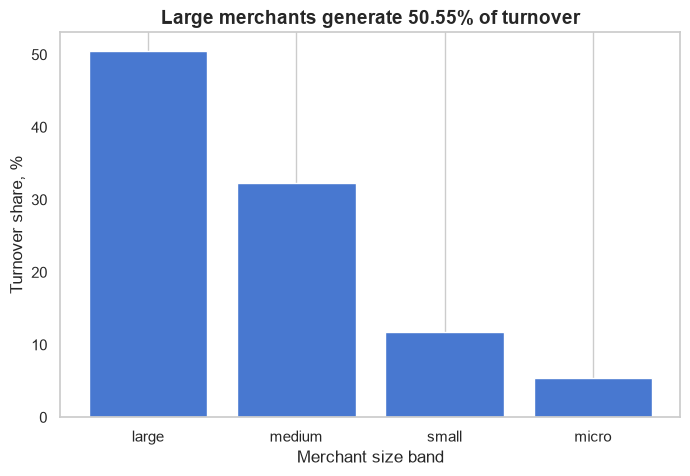

In [12]:
size_df = pd.DataFrame({
    "size_band": ["large", "medium", "small", "micro"],
    "merchant_count": [45, 143, 307, 622],
    "txn_count": [24327, 23358, 15087, 9312],
    "turnover_uzs": [11757624800, 7514278000, 2738769700, 1261857800],
    "turnover_share_pct": [50.55, 32.25, 11.78, 5.42],
    "avg_turnover_per_merchant": [261280551, 52547399, 8921074, 2028710]
})

plt.figure(figsize=(8, 5))
plt.bar(size_df["size_band"], size_df["turnover_share_pct"])
plt.title("Large merchants generate 50.55% of turnover")
plt.xlabel("Merchant size band")
plt.ylabel("Turnover share, %")
plt.grid(axis="y")
plt.show()

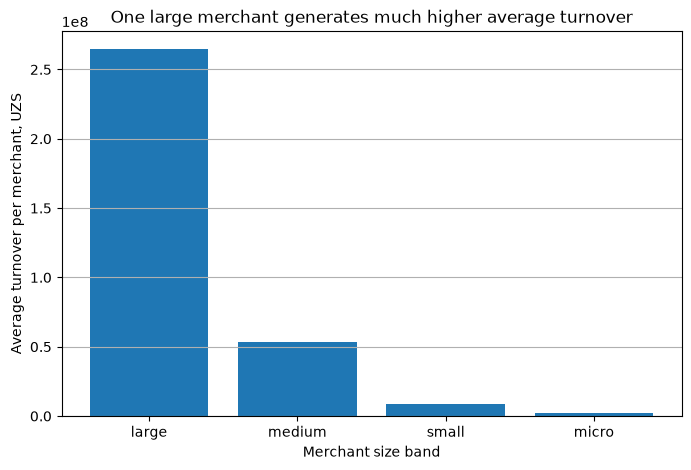

In [3]:
plt.figure(figsize=(8, 5))
plt.bar(size_df["size_band"], size_df["avg_turnover_per_merchant"])

plt.title("One large merchant generates much higher average turnover")
plt.xlabel("Merchant size band")
plt.ylabel("Average turnover per merchant, UZS")
plt.grid(axis="y")
plt.show()

## Глубокий Анализ

In [6]:
query_merchant_turnover = """
WITH merchant_turnover AS (
    SELECT
        m.merchant_id,
        m.brand_name,
        m.size_band,
        mc.category_name,
        SUM(t.amount_uzs) AS turnover_uzs,
        COUNT(*) AS txn_count
    FROM public.ds_transactions_1 t
    JOIN public.ds_terminals_1 term
        ON t.terminal_id = term.terminal_id
    JOIN public.ds_merchants_1 m
        ON term.merchant_id = m.merchant_id
    JOIN public.ds_merchant_categories mc
        ON m.category_id = mc.category_id
    WHERE t.status = 'approved'
    GROUP BY
        m.merchant_id,
        m.brand_name,
        m.size_band,
        mc.category_name
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (ORDER BY turnover_uzs DESC) AS merchant_rank,
        SUM(turnover_uzs) OVER () AS total_turnover,
        SUM(turnover_uzs) OVER (
            ORDER BY turnover_uzs DESC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS cumulative_turnover
    FROM merchant_turnover
)
SELECT
    merchant_id,
    brand_name,
    size_band,
    category_name,
    turnover_uzs,
    txn_count,
    merchant_rank,
    ROUND(100.0 * turnover_uzs / total_turnover, 2) AS turnover_share_pct,
    ROUND(100.0 * cumulative_turnover / total_turnover, 2) AS cumulative_share_pct
FROM ranked
ORDER BY turnover_uzs DESC;
"""

merchant_df = pd.read_sql(query_merchant_turnover, conn)

merchant_df.head()

/var/folders/7r/l55tlv913fd40895kn_wpch80000gn/T/ipykernel_12206/1318473811.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  merchant_df = pd.read_sql(query_merchant_turnover, conn)


,merchant_id,brand_name,size_band,category_name,turnover_uzs,txn_count,merchant_rank,turnover_share_pct,cumulative_share_pct
0,212,Brand212,large,Jewelry,1.482589e+09,940,1,6.30,6.30
1,1159,Brand1159,large,Hotel,1.215823e+09,791,2,5.16,11.46
2,502,Brand502,large,Travel,9.309731e+08,583,3,3.95,15.41
3,662,Brand662,large,Travel,8.418658e+08,551,4,3.58,18.99
4,361,Brand361,large,Marketplace,4.376582e+08,755,5,1.86,20.85


In [7]:
total_merchants = merchant_df["merchant_id"].nunique()
total_turnover = merchant_df["turnover_uzs"].sum()

top_10_share = merchant_df.head(10)["turnover_uzs"].sum() / total_turnover * 100
top_20_share = merchant_df.head(20)["turnover_uzs"].sum() / total_turnover * 100
top_50_share = merchant_df.head(50)["turnover_uzs"].sum() / total_turnover * 100

print("Total merchants:", total_merchants)
print("Total turnover:", total_turnover)
print("Top-10 turnover share:", round(top_10_share, 2), "%")
print("Top-20 turnover share:", round(top_20_share, 2), "%")
print("Top-50 turnover share:", round(top_50_share, 2), "%")

Total merchants: 1117
Total turnover: 23544992500.0
Top-10 turnover share: 27.72 %
Top-20 turnover share: 39.1 %
Top-50 turnover share: 60.25 %


In [8]:
query_size_band = """
WITH merchant_turnover AS (
    SELECT
        m.merchant_id,
        m.brand_name,
        m.size_band,
        SUM(t.amount_uzs) AS turnover_uzs,
        COUNT(*) AS txn_count
    FROM public.ds_transactions_1 t
    JOIN public.ds_terminals_1 term
        ON t.terminal_id = term.terminal_id
    JOIN public.ds_merchants_1 m
        ON term.merchant_id = m.merchant_id
    WHERE t.status = 'approved'
    GROUP BY
        m.merchant_id,
        m.brand_name,
        m.size_band
),
size_band_summary AS (
    SELECT
        size_band,
        COUNT(*) AS merchant_count,
        SUM(txn_count) AS txn_count,
        SUM(turnover_uzs) AS turnover_uzs,
        AVG(turnover_uzs) AS avg_turnover_per_merchant
    FROM merchant_turnover
    GROUP BY size_band
)
SELECT
    size_band,
    merchant_count,
    txn_count,
    turnover_uzs,
    ROUND(100.0 * turnover_uzs / SUM(turnover_uzs) OVER (), 2) AS turnover_share_pct,
    ROUND(avg_turnover_per_merchant, 2) AS avg_turnover_per_merchant
FROM size_band_summary
ORDER BY turnover_uzs DESC;
"""

size_df = pd.read_sql(query_size_band, conn)

size_df

/var/folders/7r/l55tlv913fd40895kn_wpch80000gn/T/ipykernel_12206/1392748633.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  size_df = pd.read_sql(query_size_band, conn)


,size_band,merchant_count,txn_count,turnover_uzs,turnover_share_pct,avg_turnover_per_merchant
0,large,45,24620.0,1.190159e+10,50.55,2.644798e+08
1,medium,143,24145.0,7.593193e+09,32.25,5.309925e+07
2,small,307,15287.0,2.773179e+09,11.78,9.033156e+06
3,micro,622,9413.0,1.277029e+09,5.42,2.053101e+06


In [9]:
large_merchants = size_df.loc[size_df["size_band"] == "large", "merchant_count"].iloc[0]
total_merchants = size_df["merchant_count"].sum()

large_merchant_share = large_merchants / total_merchants * 100

print("Large merchants count:", large_merchants)
print("Total merchants:", total_merchants)
print("Large merchants share:", round(large_merchant_share, 2), "%")

Large merchants count: 45
Total merchants: 1117
Large merchants share: 4.03 %


In [10]:
query_top50_size_band = """
WITH merchant_turnover AS (
    SELECT
        m.merchant_id,
        m.brand_name,
        m.size_band,
        SUM(t.amount_uzs) AS turnover_uzs
    FROM public.ds_transactions_1 t
    JOIN public.ds_terminals_1 term
        ON t.terminal_id = term.terminal_id
    JOIN public.ds_merchants_1 m
        ON term.merchant_id = m.merchant_id
    WHERE t.status = 'approved'
    GROUP BY
        m.merchant_id,
        m.brand_name,
        m.size_band
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (ORDER BY turnover_uzs DESC) AS merchant_rank
    FROM merchant_turnover
)
SELECT
    size_band,
    COUNT(*) AS merchants_in_top_50,
    SUM(turnover_uzs) AS turnover_uzs
FROM ranked
WHERE merchant_rank <= 50
GROUP BY size_band
ORDER BY turnover_uzs DESC;
"""

top50_size_df = pd.read_sql(query_top50_size_band, conn)

top50_size_df

/var/folders/7r/l55tlv913fd40895kn_wpch80000gn/T/ipykernel_12206/1878194717.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top50_size_df = pd.read_sql(query_top50_size_band, conn)


,size_band,merchants_in_top_50,turnover_uzs
0,large,35,1.117773e+10
1,medium,15,3.009082e+09


In [11]:
top50_size_df["merchant_share_in_top50_pct"] = (
    top50_size_df["merchants_in_top_50"] / top50_size_df["merchants_in_top_50"].sum() * 100
)

top50_size_df["turnover_share_in_top50_pct"] = (
    top50_size_df["turnover_uzs"] / top50_size_df["turnover_uzs"].sum() * 100
)

top50_size_df

,size_band,merchants_in_top_50,turnover_uzs,merchant_share_in_top50_pct,turnover_share_in_top50_pct
0,large,35,1.117773e+10,70.0,78.78959
1,medium,15,3.009082e+09,30.0,21.21041


H0: распределение оборота одинаковое для всех size_band.
H1: хотя бы один size_band отличается по обороту.

In [15]:
large_turnover = merchant_df.loc[
    merchant_df["size_band"] == "large",
    "turnover_uzs"
]

medium_turnover = merchant_df.loc[
    merchant_df["size_band"] == "medium",
    "turnover_uzs"
]

small_turnover = merchant_df.loc[
    merchant_df["size_band"] == "small",
    "turnover_uzs"
]

micro_turnover = merchant_df.loc[
    merchant_df["size_band"] == "micro",
    "turnover_uzs"
]

print("large:", len(large_turnover))
print("medium:", len(medium_turnover))
print("small:", len(small_turnover))
print("micro:", len(micro_turnover))

large: 45
medium: 143
small: 307
micro: 622


In [19]:
sql("""
WITH merchant_financials AS (
    SELECT
        m.merchant_id,
        m.brand_name,
        m.size_band,
        m.settlement_account_bank,
        t.terminal_id,
        t.terminal_type,
        txn.txn_id,
        txn.amount_uzs,
        txn.status AS txn_status,
        txn.is_cross_region,
        s.batch_date,
        s.settled_ts,
        -- Расчет задержки выплаты в часах/днях (для гипотезы Ислама)
        EXTRACT(EPOCH FROM (s.settled_ts - s.batch_date))/3600 AS settlement_delay_hours,
        s.commission_uzs,
        s.net_amount_uzs
    FROM public.ds_transactions_1 txn
    INNER JOIN public.ds_terminals_1 t ON txn.terminal_id = t.terminal_id
    INNER JOIN public.ds_merchants_1 m ON t.merchant_id = m.merchant_id
    LEFT JOIN public.ds_settlements s ON txn.settlement_id = s.settlement_id
)
SELECT
    merchant_id,
    brand_name,
    size_band,
    settlement_account_bank,
    COUNT(txn_id) AS total_transactions,
    SUM(amount_uzs) AS total_volume_uzs,
    AVG(settlement_delay_hours) AS avg_delay_hours,
    SUM(SUM(amount_uzs)) OVER(PARTITION BY settlement_account_bank) AS bank_total_volume,
    ROUND(SUM(amount_uzs) * 100.0 / SUM(SUM(amount_uzs)) OVER(PARTITION BY settlement_account_bank), 2) AS merchant_share_in_bank_pct
FROM merchant_financials
WHERE txn_status = 'approved'
GROUP BY merchant_id, brand_name, size_band, settlement_account_bank;
""")

/var/folders/7r/l55tlv913fd40895kn_wpch80000gn/T/ipykernel_12206/1661680024.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,merchant_id,brand_name,size_band,settlement_account_bank,total_transactions,total_volume_uzs,avg_delay_hours,bank_total_volume,merchant_share_in_bank_pct
0,447,Brand447,micro,Agrobank,5,355600.0,116.600000,3.290357e+09,0.01
1,944,Brand944,small,Agrobank,21,4177800.0,93.047619,3.290357e+09,0.13
2,164,Brand164,micro,Agrobank,31,2363100.0,88.419355,3.290357e+09,0.07
3,630,Brand630,micro,Agrobank,16,1755200.0,88.312500,3.290357e+09,0.05
4,989,Brand989,micro,Agrobank,7,462200.0,80.571429,3.290357e+09,0.01
...,...,...,...,...,...,...,...,...,...
1112,926,Brand926,micro,NBU,38,3492700.0,50.894737,4.499168e+09,0.08
1113,1109,Brand1109,small,NBU,40,5273600.0,53.564103,4.499168e+09,0.12
1114,722,Brand722,micro,NBU,11,5974700.0,49.272727,4.499168e+09,0.13
1115,710,Brand710,medium,NBU,211,82068500.0,55.602871,4.499168e+09,1.82


In [22]:
sql("""
SELECT
    m.size_band,
    COUNT(t.txn_id) AS total_transactions,
    SUM(t.amount_uzs) AS total_volume_uzs,
    ROUND(AVG(t.amount_uzs), 2) AS avg_check_uzs,
    -- Дополнительно посчитаем долю транзакций сегмента от общего числа
    ROUND(COUNT(t.txn_id) * 100.0 / SUM(COUNT(t.txn_id)) OVER(), 2) AS txn_share_pct
FROM public.ds_transactions_1 t
INNER JOIN public.ds_terminals_1 term ON t.terminal_id = term.terminal_id
INNER JOIN public.ds_merchants_1 m ON term.merchant_id = m.merchant_id
WHERE t.status = 'approved' -- Раскомментируйте, если бизнес считает только успешные платежи
GROUP BY m.size_band
ORDER BY total_volume_uzs DESC;
""")

/var/folders/7r/l55tlv913fd40895kn_wpch80000gn/T/ipykernel_12206/1661680024.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,size_band,total_transactions,total_volume_uzs,avg_check_uzs,txn_share_pct
0,large,24620,1.190159e+10,483411.52,33.51
1,medium,24145,7.593193e+09,314483.04,32.87
2,small,15287,2.773179e+09,181407.67,20.81
3,micro,9413,1.277029e+09,135666.53,12.81


In [23]:
sql("""
SELECT
    m.size_band,
    COUNT(s.settlement_id) AS total_settlement_batches,
    SUM(s.gross_amount_uzs) AS total_gross_volume_uzs,
    SUM(s.commission_uzs) AS total_commission_revenue_uzs,
    -- Эффективная ставка комиссии (сколько реально зарабатывает кошелек в % от оборота)
    ROUND((SUM(s.commission_uzs) * 100.0 / NULLIF(SUM(s.gross_amount_uzs), 0))::numeric, 2) AS effective_commission_rate_pct,
    -- Доля каждого сегмента в общей комиссионной прибыли компании
    ROUND((SUM(s.commission_uzs) * 100.0 / SUM(SUM(s.commission_uzs)) OVER())::numeric, 2) AS commission_revenue_share_pct
FROM public.ds_settlements s
INNER JOIN public.ds_merchants_1 m ON s.merchant_id = m.merchant_id
GROUP BY m.size_band
ORDER BY total_commission_revenue_uzs DESC;
""")

/var/folders/7r/l55tlv913fd40895kn_wpch80000gn/T/ipykernel_12206/1661680024.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,size_band,total_settlement_batches,total_gross_volume_uzs,total_commission_revenue_uzs,effective_commission_rate_pct,commission_revenue_share_pct
0,large,10924,1.175762e+10,177775093.0,1.51,51.37
1,medium,17516,7.514278e+09,113738356.0,1.51,32.87
2,small,13585,2.738770e+09,37200341.0,1.36,10.75
3,micro,9027,1.261858e+09,17328670.0,1.37,5.01


In [35]:
df = sql("""
WITH merchant_turnover AS (
    SELECT
        m.merchant_id,
        m.size_band,
        COUNT(t.txn_id) FILTER (WHERE t.status = 'approved')        AS successful_txns,  -- подставить реальное значение status
        SUM(t.amount_uzs) FILTER (WHERE t.status = 'approved')      AS gross_uzs
    FROM ds_merchants_1 m
    JOIN ds_terminals_1 term ON term.merchant_id = m.merchant_id
    JOIN ds_transactions_1 t ON t.terminal_id = term.terminal_id
    GROUP BY m.merchant_id, m.size_band
),
merchant_commission AS (
    SELECT merchant_id, SUM(commission_uzs) AS commission_uzs
    FROM ds_settlements
    GROUP BY merchant_id
)
SELECT
    mt.size_band,
    COUNT(*)                                                                   AS n_merchants,
    SUM(mt.successful_txns)                                                    AS successful_txns,
    SUM(mt.gross_uzs)                                                          AS gross_uzs,
    SUM(mc.commission_uzs)                                                     AS commission_uzs,
    ROUND(100.0 * SUM(mc.commission_uzs) / NULLIF(SUM(mt.gross_uzs), 0), 2)    AS effective_rate_pct
FROM merchant_turnover mt
JOIN merchant_commission mc ON mc.merchant_id = mt.merchant_id
GROUP BY mt.size_band
ORDER BY gross_uzs DESC;
""")

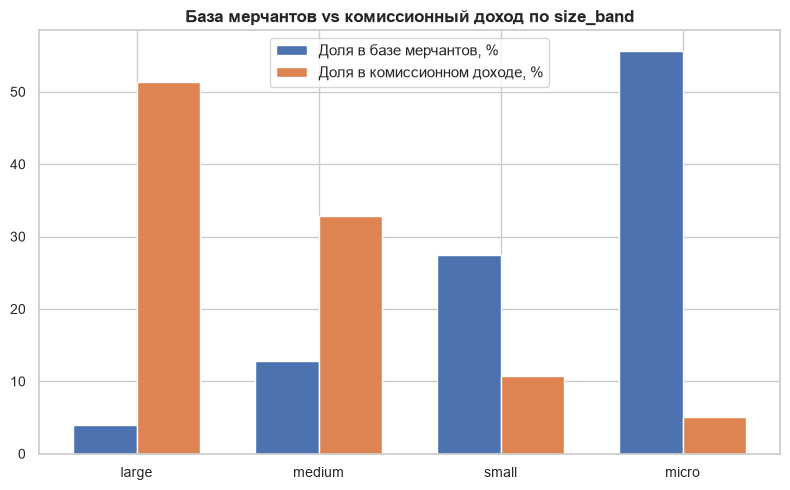

In [36]:
x = np.arange(len(df))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, df['n_merchants'] / df['n_merchants'].sum() * 100, width, label='Доля в базе мерчантов, %')
ax.bar(x + width/2, df['commission_uzs'] / df['commission_uzs'].sum() * 100, width, label='Доля в комиссионном доходе, %')
ax.set_xticks(x)
ax.set_xticklabels(df['size_band'])
ax.legend()
ax.set_title('База мерчантов vs комиссионный доход по size_band')
plt.tight_layout()
plt.show()


# Гипотеза 1 (H1): Выводы

---

## Бизнес-контекст

* **Ситуация (Situation):** MerchantHub развивает сеть эквайринга, распределяя клиентов по четырем сегментам (`size_band`): Large, Medium, Small, Micro
* **Осложнение (Complication):** Операционный объем и чистый доход критически зависят от узкой группы клиентов.
* **Вопрос (Question):** Какова реальная степень зависимости бизнеса от крупнейших игроков ?
* **Ответ (Answer / Главный вывод):** Бизнес находится в зоне острой концентрации риска: всего 4.03% клиентов (сегмент Large) генерируют 50.55% оборота и 51.37% комиссионной прибыли.

---

## Сводные аналитические данные по сегментам

Данные очищены от неуспешных операций и агрегированы по результатам финансового контура расчетов:

| Метрика / Сегмент | Large | Medium | Small | Micro | Итого / Всего |
| --- | --- | --- | --- | --- | --- |
| **Количество мерчантов** | 45 (4.03%) | 143 (12.80%) | 307 (27.48%) | 622 (55.68%) | **1 117 (100%)** |
| **Успешные транзакции** | 24 620 (33.51%) | 24 145 (32.87%) | 15 287 (20.81%) | 9 413 (12.81%) | **73 465 (100%)** |
| **Грязный оборот (Gross, UZS)** | 11.76 млрд (50.55%) | 7.51 млрд (32.25%) | 2.74 млрд (11.78%) | 1.26 млрд (5.42%) | **23.27 млрд (100%)** |
| **Комиссия эквайера (Revenue, UZS)** | 177.78 млн (51.37%) | 113.74 млн (32.87%) | 37.20 млн (10.75%) | 17.33 млн (5.01%) | **346.04 млн (100%)** |
| **Эффективная ставка комиссии** | **1.51%** | **1.51%** | **1.36%** | **1.37%** | **1.49% (средняя)** |
---

## Разбор находки

- Классическое распределение Парето (80/20) опровергнуто фактической структурой данных — дисбаланс MerchantHub развит значительно сильнее. Вся финансовая стабильность компании удерживается силами 45 брендов (`large`), в то время как «длинный хвост» из 622 микробрендов выполняет роль неэффективного операционного балласта с точки зрения чистой маржи.
- Два верхних сегмента (`large` + `medium`) полностью контролируют **84.24% комиссионных доходов** MerchantHub.

## Доп Графики для презы

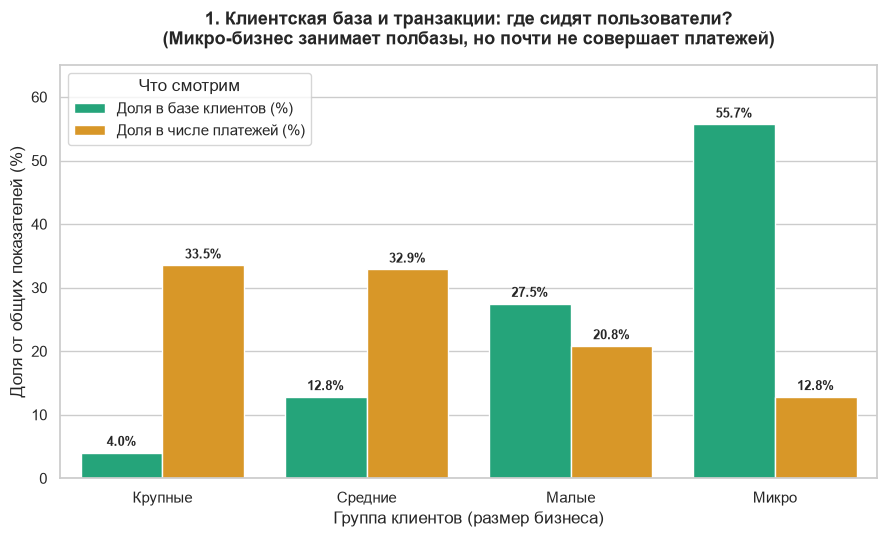

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

data = {
    'Сегмент': ['Крупные', 'Средние', 'Малые', 'Микро'],
    'Доля в базе клиентов (%)': [4.03, 12.80, 27.48, 55.68],
    'Доля в числе платежей (%)': [33.51, 32.87, 20.81, 12.81],
    'Доля в общем обороте (%)': [50.55, 32.25, 11.78, 5.42],
    'Доля в доходе компании (%)': [51.37, 32.87, 10.75, 5.01]
}
df = pd.DataFrame(data)

# ==============================================================================
# ГРАФИК 1: КЛИЕНТЫ И ОПЕРАЦИИ
# ==============================================================================
df_melted1 = df.melt(
    id_vars='Сегмент',
    value_vars=['Доля в базе клиентов (%)', 'Доля в числе платежей (%)'],
    var_name='Показатель',
    value_name='Процент'
)

plt.figure(figsize=(9, 5.5))
palette1 = {
    'Доля в базе клиентов (%)': '#10B981',   # Яркий изумрудно-зеленый
    'Доля в числе платежей (%)': '#F59E0B'  # Яркий янтарно-желтый
}

ax1 = sns.barplot(x='Сегмент', y='Процент', hue='Показатель', data=df_melted1, palette=palette1)

# Добавление подписей данных над столбцами
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(f'{height:.1f}%',
                     xy=(p.get_x() + p.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title("1. Клиентская база и транзакции: где сидят пользователи?\n(Микро-бизнес занимает полбазы, но почти не совершает платежей)", pad=15, fontweight='bold')
plt.ylabel("Доля от общих показателей (%)")
plt.xlabel("Группа клиентов (размер бизнеса)")
plt.ylim(0, 65)
plt.legend(title="Что смотрим", loc='upper left')
plt.tight_layout()

# Сохранение первого графика
plt.savefig('plot1_clients_and_transactions.png', dpi=300)
plt.show()

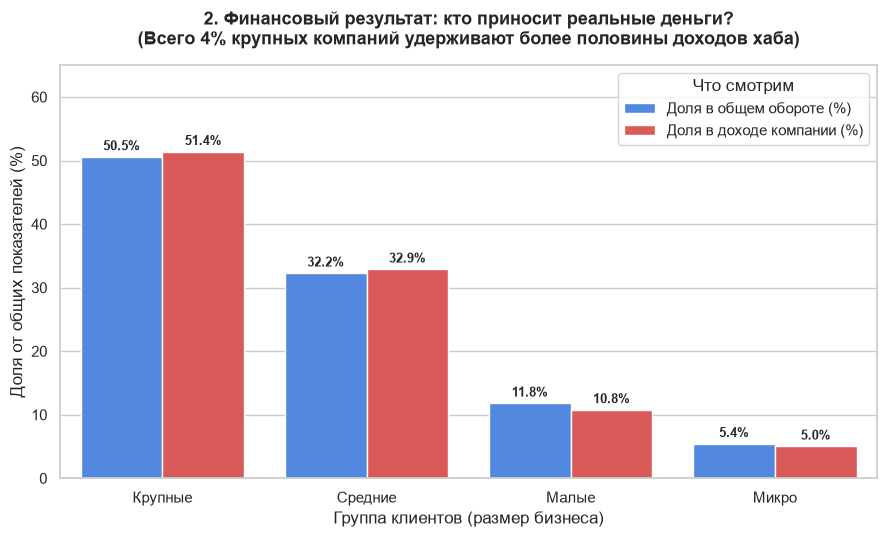

In [ ]:

# ==============================================================================
# ГРАФИК 2: ОБОРОТ И ДОХОД
# ==============================================================================
df_melted2 = df.melt(
    id_vars='Сегмент',
    value_vars=['Доля в общем обороте (%)', 'Доля в доходе компании (%)'],
    var_name='Показатель',
    value_name='Процент'
)

plt.figure(figsize=(9, 5.5))
palette2 = {
    'Доля в общем обороте (%)': '#3B82F6',     # Яркий синий
    'Доля в доходе компании (%)': '#EF4444'     # Яркий критический красный
}

ax2 = sns.barplot(x='Сегмент', y='Процент', hue='Показатель', data=df_melted2, palette=palette2)

# Добавление подписей данных над столбцами
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        ax2.annotate(f'{height:.1f}%',
                     xy=(p.get_x() + p.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title("2. Финансовый результат: кто приносит реальные деньги?\n(Всего 4% крупных компаний удерживают более половины доходов хаба)", pad=15, fontweight='bold')
plt.ylabel("Доля от общих показателей (%)")
plt.xlabel("Группа клиентов (размер бизнеса)")
plt.ylim(0, 65)
plt.legend(title="Что смотрим", loc='upper right')
plt.tight_layout()

# Сохранение второго графика
plt.savefig('plot2_turnover_and_revenue.png', dpi=300)
plt.show()

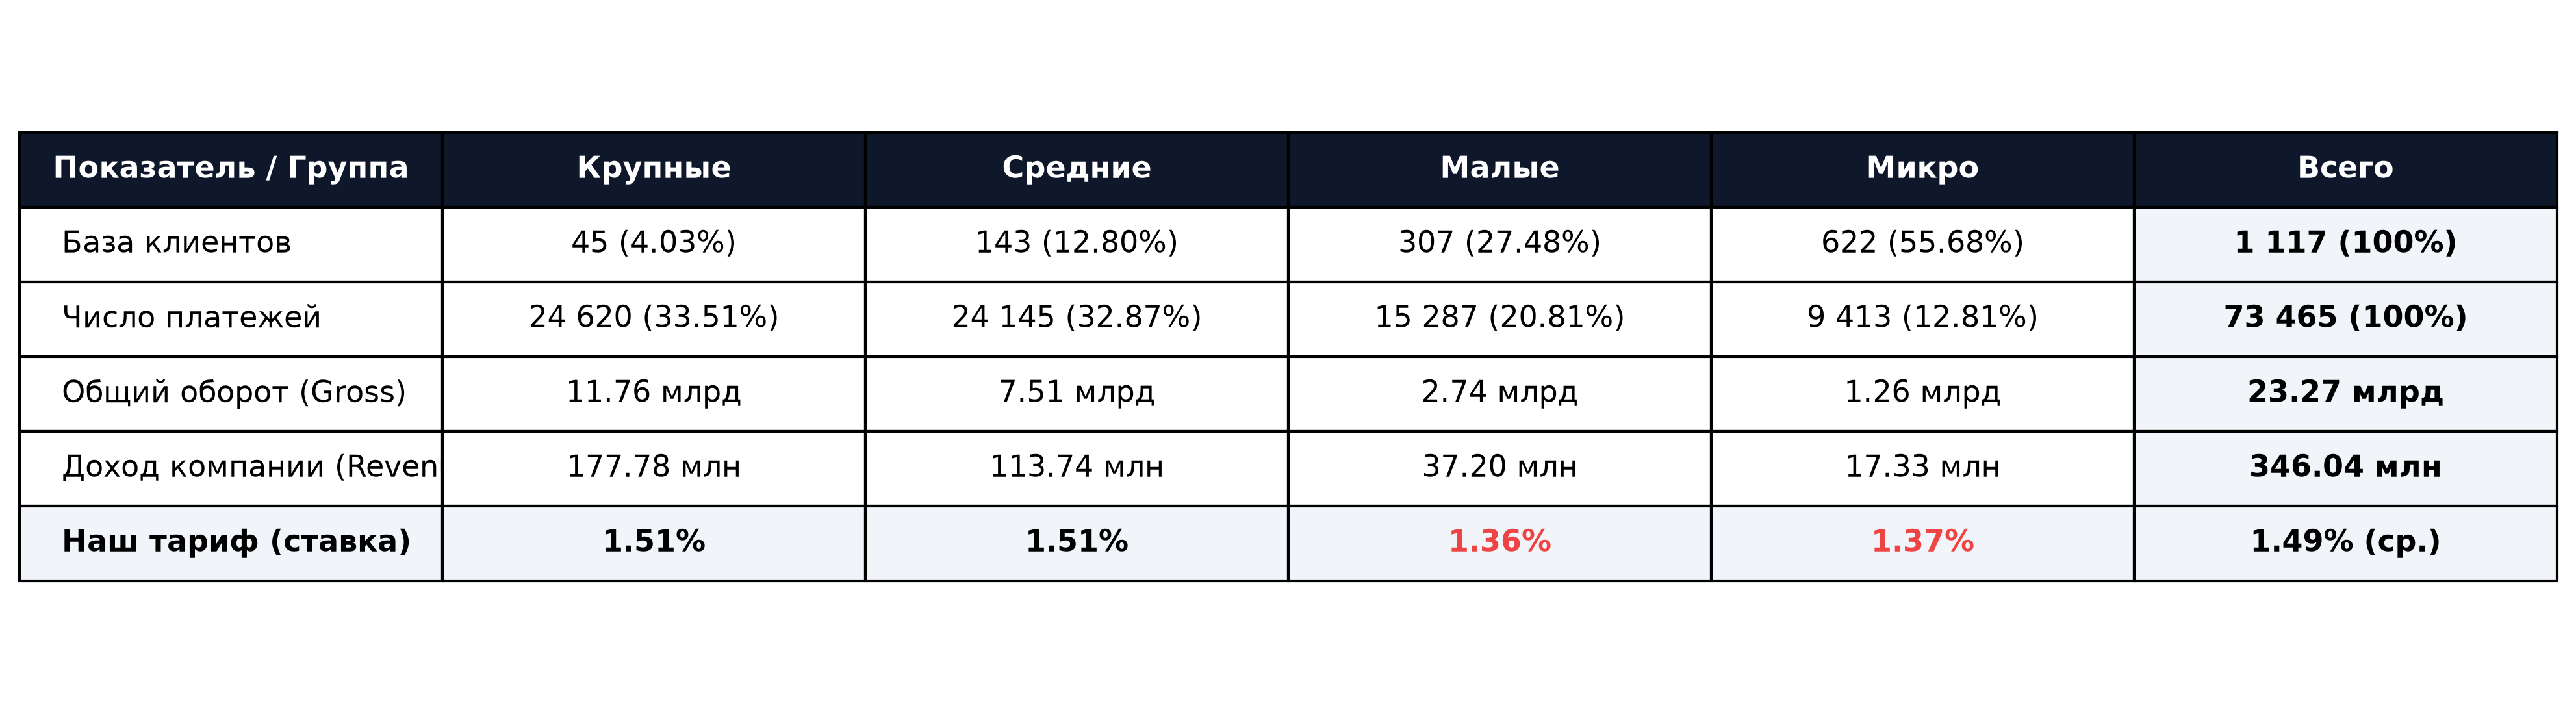

In [ ]:
import matplotlib.pyplot as plt

# Подготовка чистых данных для визуального рендеринга
columns = ["Показатель / Группа", "Крупные", "Средние", "Малые", "Микро", "Всего"]
data = [
    ["База клиентов", "45 (4.03%)", "143 (12.80%)", "307 (27.48%)", "622 (55.68%)", "1 117 (100%)"],
    ["Число платежей", "24 620 (33.51%)", "24 145 (32.87%)", "15 287 (20.81%)", "9 413 (12.81%)", "73 465 (100%)"],
    ["Общий оборот (Gross)", "11.76 млрд", "7.51 млрд", "2.74 млрд", "1.26 млрд", "23.27 млрд"],
    ["Доход компании (Revenue)", "177.78 млн", "113.74 млн", "37.20 млн", "17.33 млн", "346.04 млн"],
    ["Наш тариф (ставка)", "1.51%", "1.51%", "1.36%", "1.37%", "1.49% (ср.)"],
]

fig, ax = plt.subplots(figsize=(14, 4.5), dpi=300)
ax.axis('off')

# Создание строгой таблицы
table = ax.table(cellText=data, colLabels=columns, cellLoc='center', loc='center')

# McKinsey-style кастомизация дизайна и шрифтов
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.3) # Оптимальные отступы внутри ячеек

# Стилизация элементов
for (row, col), cell in table.get_celld().items():
    # Заголовок таблицы
    if row == 0:
        cell.set_text_props(fontweight='bold', color='white')
        cell.set_facecolor('#0F172A') # Deep Navy фон
    # Столбец итогов (последний) или итоговые строки
    elif col == 5 or row in [5]:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#F1F5F9') # Светло-серый акцент
    # Аномально заниженные тарифы (подсветка проблемы)
    if row == 5 and col in [3, 4]:
        cell.set_text_props(color='#EF4444', fontweight='bold') # Критический красный

    # Выравнивание текстового описания по левому краю для читаемости
    if col == 0 and row > 0:
        cell.set_text_props(ha='left')

plt.savefig('merchant_hub_clean_table.png', bbox_inches='tight', dpi=300)
plt.show()